# FX Option Backtesting

This notebook runs the **FX option backtester** from raw Parquet market data to a full
performance and risk analysis, for the **EUR/NOK** currency pair.

**Pipeline**
1. Load and pivot stacked market data (spot, forward curve, deposit curves, vol surface).
2. Inspect the interpolated **vol surface** (cubic spline in strike, linear in time) and curves.
3. Price a single option with **Garman-Kohlhagen** and view its Greeks.
4. Backtest multi-leg strategies (**Straddle**, **Call Ratio Spread**, **Calendar Spread**) with **daily delta hedging**.
5. Compute option-aware **performance metrics** (Sharpe, Sortino, VaR, CVaR, max drawdown).
6. **Greeks P&L attribution**: decompose daily P&L into delta / gamma / vega / theta components.
7. Add a **signal** to gate entries and compare.

> Conventions: options are priced in the **domestic currency** (NOK, the quote currency). Forward
> points are added to spot to obtain the outright. Vols are stored in % and converted to decimals.


In [1]:
import sys
from pathlib import Path

# make the package importable when running from the notebooks folder
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)

DATA_DIR = ROOT / "data"
print("Project root:", ROOT)
print("Data dir exists:", DATA_DIR.exists())


Project root: c:\Users\b304juv\OneDrive - Assicurazioni Generali S.p.A\Bureau\Trading-vol
Data dir exists: True


## 1. Load and pivot market data

`MarketDataLoader` reads the four Parquet datasets, normalises units
(vols % to decimal, rates % to decimal, forward pips to price units), and the engine
pre-pivots each stacked frame into a `{date: sub-frame}` mapping for fast
day-by-day access.


In [2]:
from src.engine import Backtester

bt = Backtester(DATA_DIR)
bt.load_data()

print("Spot:", bt._spot.shape, "|", bt._spot.index.min().date(), "to", bt._spot.index.max().date())
print("Forward rows:", bt._fwd.shape)
print("Rate rows:", bt._rates.shape, "| curves:", sorted(bt._rates['curve_id'].unique()))
print("Vol rows:", bt._vol.shape, "| maturities/day ~", bt._vol.groupby('DATE')['MATURITY'].nunique().median())

bt._spot.head(5)
bt._spot.tail(5)


Spot: (5799, 2) | 2003-12-31 to 2026-03-23
Forward rows: (53066, 5)
Rate rows: (219699, 6) | curves: [np.int64(1), np.int64(2)]
Vol rows: (1371087, 8) | maturities/day ~ 18.0


,RIC,MID_PRICE
DATE,,
2026-03-19,EURNOK=,10.99130
2026-03-20,EURNOK=,11.06800
2026-03-23,EURNOK=,11.30865


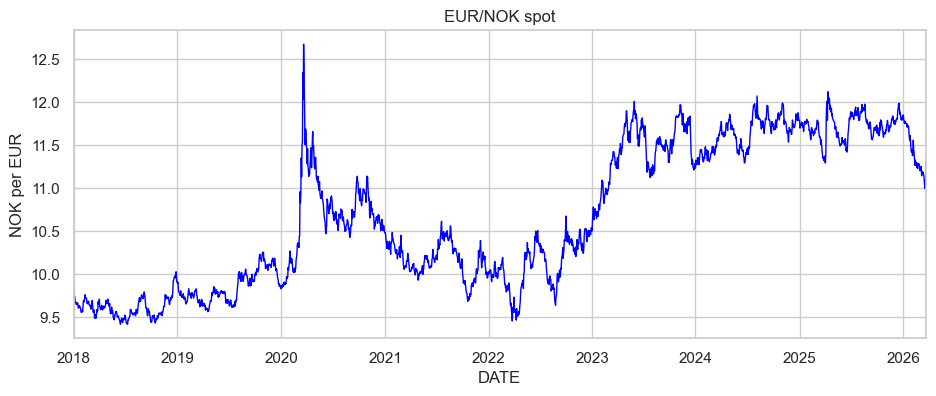

In [3]:
ax = bt._spot.loc["2018":, "MID_PRICE"].plot(color="blue", lw=1)
ax.set_title("EUR/NOK spot")
ax.set_ylabel("NOK per EUR")
plt.show()

## 2. Interpolated vol surface and curves

We rebuild the surface for one date and sample it on a dense grid to visualise
the **cubic-spline-in-strike / linear-in-time** interpolation scheme with **linear**
extrapolation beyond the quoted strike range.


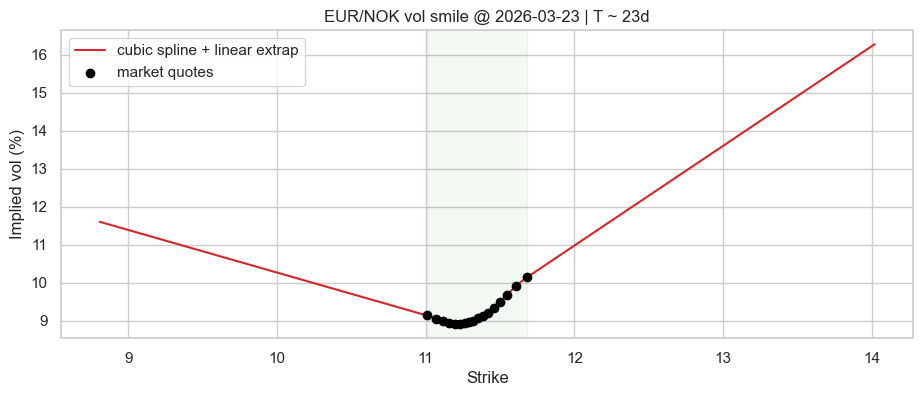

In [4]:
from src.volatility.surface import VolSurface

sample_date = bt._vol["DATE"].max()
vol_day = bt._vol[bt._vol["DATE"] == sample_date]
surf = VolSurface(vol_day)

# raw market quotes for the nearest available smile
first_mat = sorted(vol_day["MATURITY"].unique())[3]
smile_raw = vol_day[vol_day["MATURITY"] == first_mat].sort_values("MID_STRIKE")
t_smile = (first_mat - sample_date).days / 365.25

k_grid = np.linspace(smile_raw["MID_STRIKE"].min() * 0.8,
                     smile_raw["MID_STRIKE"].max() * 1.2, 250)
v_grid = [surf.get_vol(k, t_smile) for k in k_grid]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(k_grid, np.array(v_grid) * 100, label="cubic spline + linear extrap", color="#d62728")
ax.scatter(smile_raw["MID_STRIKE"], smile_raw["MID_PRICE"] * 100,
           color="black", zorder=5, label="market quotes")
ax.axvspan(smile_raw["MID_STRIKE"].min(), smile_raw["MID_STRIKE"].max(),
           alpha=0.05, color="green")
ax.set_title(f"EUR/NOK vol smile @ {sample_date.date()} | T ~ {t_smile*365:.0f}d")
ax.set_xlabel("Strike"); ax.set_ylabel("Implied vol (%)"); ax.legend()
plt.show()


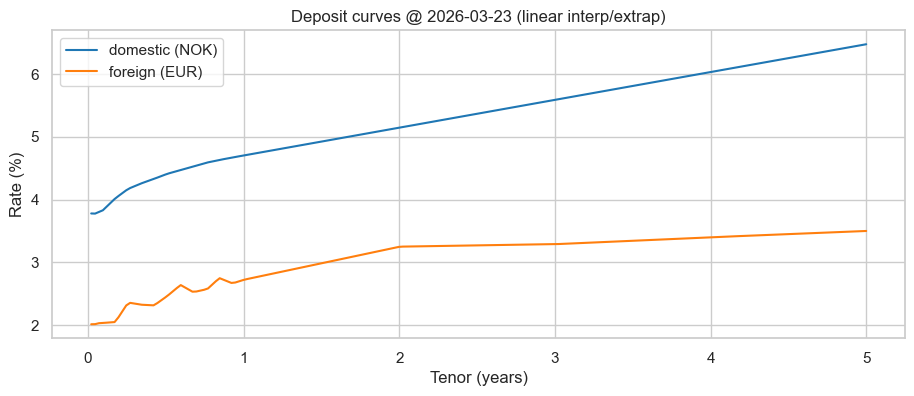

In [5]:
from src.curves.interpolator import CurveInterpolator

rd = CurveInterpolator.from_dataframe(bt._rates[bt._rates.curve_id == 1], sample_date)
rf = CurveInterpolator.from_dataframe(bt._rates[bt._rates.curve_id == 2], sample_date)

tt = np.linspace(0.02, 5.0, 200)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tt, [rd(t) * 100 for t in tt], label="domestic (NOK)", color="#1f77b4")
ax.plot(tt, [rf(t) * 100 for t in tt], label="foreign (EUR)", color="#ff7f0e")
ax.set_title(f"Deposit curves @ {sample_date.date()} (linear interp/extrap)")
ax.set_xlabel("Tenor (years)"); ax.set_ylabel("Rate (%)"); ax.legend()
plt.show()


## 3. Single-option pricing (Garman-Kohlhagen)

$$C = S\,e^{-r_f T} N(d_1) - K\,e^{-r_d T} N(d_2), \qquad
P = K\,e^{-r_d T} N(-d_2) - S\,e^{-r_f T} N(-d_1)$$

Price a 1-month ATM EUR/NOK call on the latest date, with market-implied vol and rates.


In [6]:
from src.pricing.garman_kohlhagen import garman_kohlhagen

S0 = float(bt._spot.loc[sample_date, "MID_PRICE"])
T = 30 / 365.0
fwd_day = bt._fwd[bt._fwd["DATE"] == sample_date]
fwd_interp = CurveInterpolator.from_dataframe(fwd_day, sample_date)
K_atm = S0 + float(fwd_interp(T))  # forward outright = spot + forward points
sigma = surf.get_vol(K_atm, T)

res = garman_kohlhagen(S0, K_atm, T, float(rd(T)), float(rf(T)), sigma, "call")
pd.Series({
    "Spot": S0, "Strike (fwd)": K_atm, "T (yrs)": T, "Vol": sigma,
    "r_d": float(rd(T)), "r_f": float(rf(T)),
    "Price": res.price, "Delta": res.delta, "Gamma": res.gamma,
    "Vega (per 1%)": res.vega, "Theta (per day)": res.theta,
}).round(6)


Spot               11.308650
Strike (fwd)       11.324838
T (yrs)             0.082192
Vol                 0.089120
r_d                 0.038156
r_f                 0.020329
Price               0.115267
Delta               0.504794
Gamma               1.378284
Vega (per 1%)       0.012911
Theta (per day)    -0.002185
dtype: float64

## 4. Backtest a strategy with daily delta hedging

We run a **long ATM straddle**, rolled weekly, with the engine rehedging the net
option delta with a spot position **every business day**. Total P&L equals the
option mark-to-market change plus the spot-hedge P&L.


In [7]:
from src.strategies.straddle import Straddle

START, END = "2021-01-01", "2024-12-31"
NOTIONAL = 1_000_000

straddle = Straddle(tenor_days=30, direction=1)
res_straddle = bt.run(straddle, start=START, end=END, notional=NOTIONAL, roll_freq="W-FRI")

pd.Series(res_straddle["metrics"]).round(2)


total_pnl         1301508.67
sharpe                  0.13
sortino                 0.15
max_drawdown     -2868948.08
var_95            -309447.21
cvar_95           -432438.84
win_rate                0.44
avg_daily_pnl        1249.05
volatility_ann    2494413.05
dtype: float64

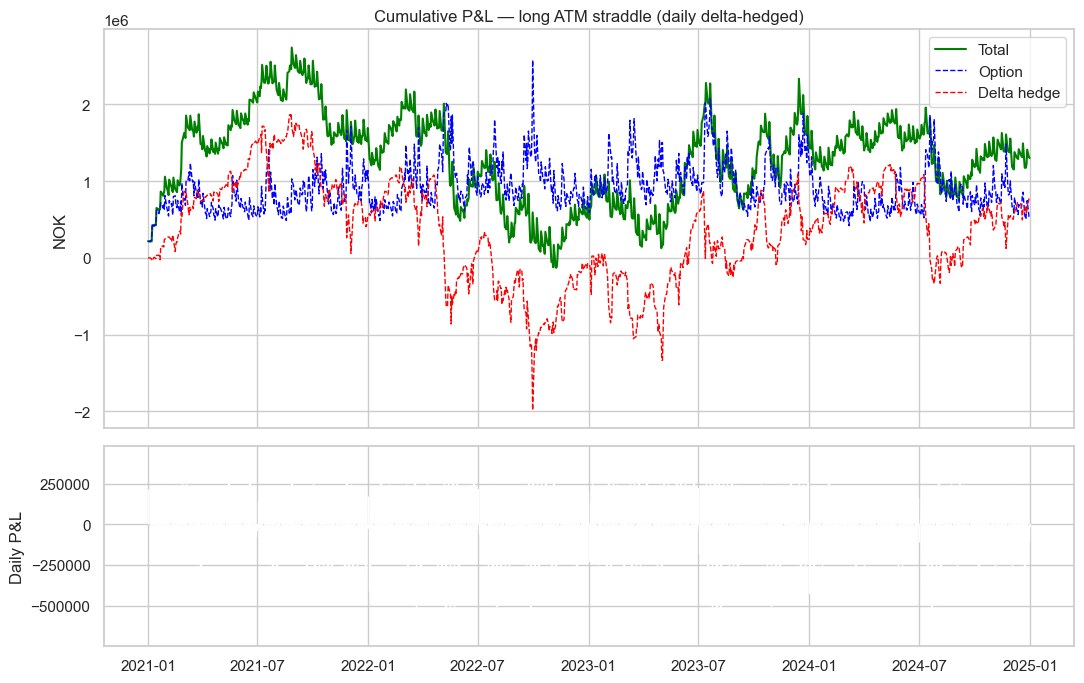

In [8]:
pnl = res_straddle["daily_pnl"]
comp = res_straddle["components"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(pnl.cumsum(), color="green", label="Total")
axes[0].plot(comp["option_pnl"].cumsum(), color="blue", lw=1, ls="--", label="Option")
axes[0].plot(comp["hedge_pnl"].cumsum(), color="red", lw=1, ls="--", label="Delta hedge")
axes[0].set_title("Cumulative P&L — long ATM straddle (daily delta-hedged)")
axes[0].set_ylabel("NOK"); axes[0].legend()

axes[1].bar(pnl.index, pnl.values,
            color=np.where(pnl.values >= 0, "green", "red"), width=1)
axes[1].set_ylabel("Daily P&L")
plt.tight_layout(); plt.show()


## 5. Compare the three strategies

Run the **Straddle**, **Call Ratio Spread** and **Calendar Spread** over the same
window and compare their option-aware performance metrics side by side.


In [9]:
from src.strategies.ratio_spread import CallRatioSpread
from src.strategies.calendar_spread import CalendarSpread

strategies = {
    "Straddle": Straddle(tenor_days=30, direction=1),
    "Call Ratio Spread": CallRatioSpread(tenor_days=30, otm_delta=0.25),
    "Calendar Spread": CalendarSpread(near_tenor_days=30, far_tenor_days=90),
}

runs, summary = {}, {}
for name, strat in strategies.items():
    r = bt.run(strat, start=START, end=END, notional=NOTIONAL, roll_freq="W-FRI")
    runs[name] = r
    summary[name] = r["metrics"]

summary_df = pd.DataFrame(summary).T
summary_df[["total_pnl", "sharpe", "sortino", "max_drawdown", "var_95", "cvar_95", "win_rate"]].round(2)


,total_pnl,sharpe,sortino,max_drawdown,var_95,cvar_95,win_rate
Straddle,1301508.67,0.13,0.15,-2868948.08,-309447.21,-432438.84,0.44
Call Ratio Spread,-621602.49,-0.21,-0.20,-1989482.92,-92863.26,-140339.22,0.61
Calendar Spread,-1868529.63,-0.16,-0.15,-11905183.67,-321214.56,-568263.57,0.51


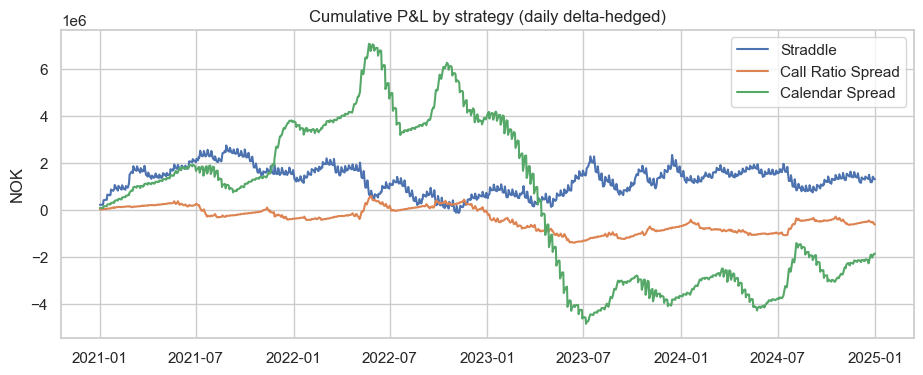

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, r in runs.items():
    ax.plot(r["daily_pnl"].cumsum(), label=name)
ax.set_title("Cumulative P&L by strategy (daily delta-hedged)")
ax.set_ylabel("NOK"); ax.legend()
plt.show()

## 6. Greeks P&L attribution

Decompose the straddle's daily option P&L into its risk-factor contributions via a
second-order Taylor expansion:

$$dP \approx \underbrace{\Delta\,dS + \text{hedge}}_{\text{delta (hedged)}}
+ \tfrac12\,\Gamma\,dS^2 + \nu\,d\sigma + \Theta\,dt + \varepsilon$$

The attribution is computed **position-by-position** over legs alive on both days, so
premium paid/received on rolls does not leak into the decomposition.


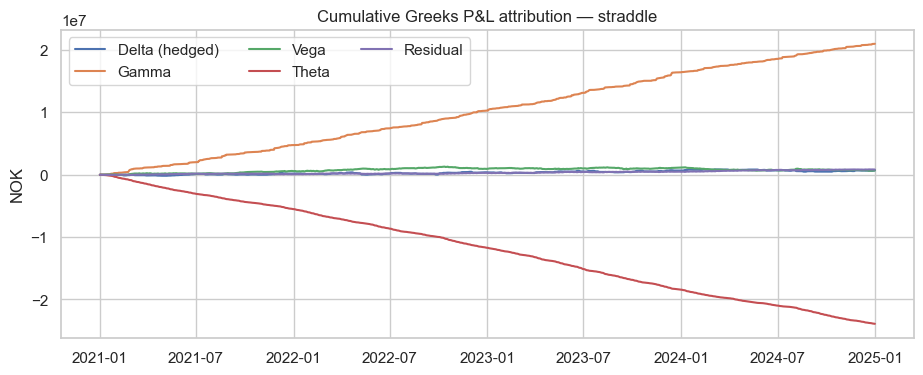

,Total contribution (NOK)
delta_pnl,702007.0
gamma_pnl,21005029.0
vega_pnl,697028.0
theta_pnl,-23900481.0
residual_pnl,838062.0


In [11]:
attr = res_straddle["attribution"]
attr_cum = attr.cumsum()

fig, ax = plt.subplots(figsize=(11, 4))
labels = {"delta_pnl": "Delta (hedged)", "gamma_pnl": "Gamma",
          "vega_pnl": "Vega", "theta_pnl": "Theta", "residual_pnl": "Residual"}
for col, lab in labels.items():
    ax.plot(attr_cum[col], label=lab)
ax.set_title("Cumulative Greeks P&L attribution — straddle")
ax.set_ylabel("NOK"); ax.legend(ncol=3)
plt.show()

attr.sum().rename("Total contribution (NOK)").round(0).to_frame()

## 7. Signal integration

Gate straddle entries with a simple **momentum filter** (trade only when spot is above
its 20-day moving average) and compare against the always-on version.


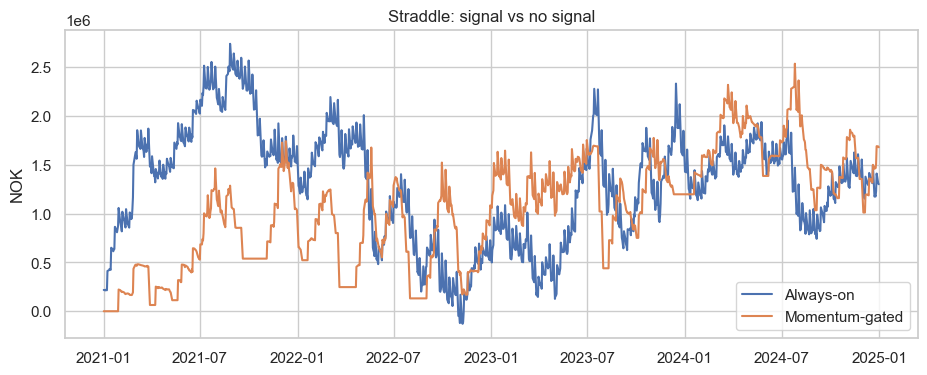

,total_pnl,sharpe,sortino,max_drawdown,win_rate
Always-on,1301508.67,0.13,0.15,-2868948.08,0.44
Momentum-gated,1680205.09,0.23,0.24,-1611196.16,0.34


In [12]:
from src.strategies.signals import momentum_signal

straddle_sig = Straddle(tenor_days=30, direction=1,
                        signal_fn=lambda h: momentum_signal(h, lookback=20))
res_sig = bt.run(straddle_sig, start=START, end=END, notional=NOTIONAL, roll_freq="W-FRI")

cmp = pd.DataFrame({
    "Always-on": res_straddle["metrics"],
    "Momentum-gated": res_sig["metrics"],
}).T[["total_pnl", "sharpe", "sortino", "max_drawdown", "win_rate"]]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(res_straddle["daily_pnl"].cumsum(), label="Always-on")
ax.plot(res_sig["daily_pnl"].cumsum(), label="Momentum-gated")
ax.set_title("Straddle: signal vs no signal"); ax.set_ylabel("NOK"); ax.legend()
plt.show()

cmp.round(2)


## 7b. Realised vol vs implied vol — visualising the gamma harvest thesis

The straddle makes money when **realised vol > implied vol paid**. Plotting these two series
side-by-side reveals when the strategy was in-the-money from a volatility-carry perspective.

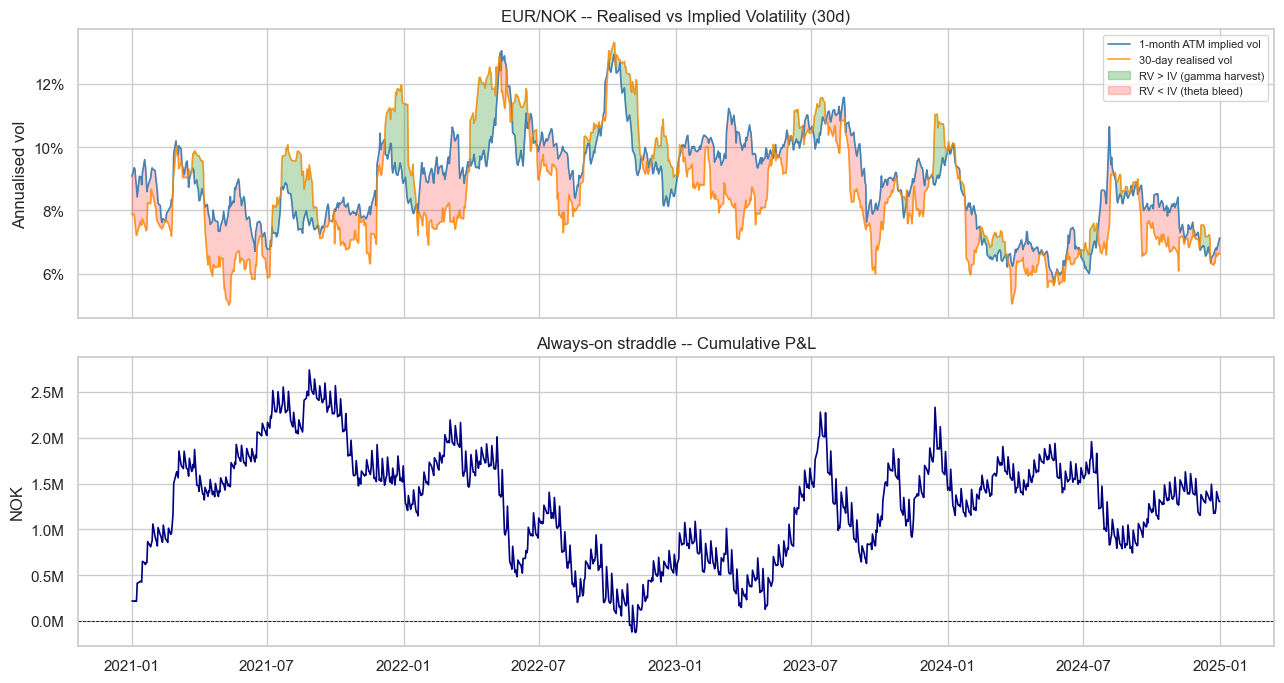

Avg vol carry (RV - IV): -0.34%  |  % days RV > IV: 34.6%


In [13]:
import warnings

# -- 30-day rolling realised vol (annualised)
spot_rets = bt._spot["MID_PRICE"].pct_change().dropna()
realized_vol_30 = spot_rets.rolling(30).std() * np.sqrt(252)

# -- 1-month ATM implied vol: one sample per date from the pre-built surface
atm_iv_series = {}
for date, vs in bt._vol_surfaces.items():
    if vs.is_empty:
        continue
    if date not in bt._spot.index:
        continue
    S_d = float(bt._spot.loc[date, "MID_PRICE"])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        iv = vs.get_vol(S_d, 30 / 365.25)
    if np.isfinite(iv) and iv > 0:
        atm_iv_series[date] = iv

atm_iv = pd.Series(atm_iv_series).sort_index()

# -- clip series to the backtest window
mask_rv = (realized_vol_30.index >= START) & (realized_vol_30.index <= END)
mask_iv = (atm_iv.index >= START) & (atm_iv.index <= END)
rv_plot = realized_vol_30[mask_rv].dropna()
iv_plot = atm_iv[mask_iv]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# top panel: realised vol vs implied vol
axes[0].plot(iv_plot, label="1-month ATM implied vol", color="steelblue", linewidth=1.2)
axes[0].plot(rv_plot, label="30-day realised vol", color="darkorange", linewidth=1.2, alpha=0.8)
axes[0].fill_between(
    rv_plot.index,
    iv_plot.reindex(rv_plot.index).ffill(),
    rv_plot,
    where=(rv_plot > iv_plot.reindex(rv_plot.index).ffill()),
    alpha=0.25, color="green", label="RV > IV (gamma harvest)"
)
axes[0].fill_between(
    rv_plot.index,
    iv_plot.reindex(rv_plot.index).ffill(),
    rv_plot,
    where=(rv_plot <= iv_plot.reindex(rv_plot.index).ffill()),
    alpha=0.20, color="red", label="RV < IV (theta bleed)"
)
axes[0].set_title("EUR/NOK -- Realised vs Implied Volatility (30d)")
axes[0].set_ylabel("Annualised vol")
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# bottom panel: cumulative P&L of the always-on straddle
axes[1].plot(res_straddle["daily_pnl"].cumsum(), color="navy", linewidth=1.2)
axes[1].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[1].set_title("Always-on straddle -- Cumulative P&L")
axes[1].set_ylabel("NOK")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y/1e6:.1f}M"))

plt.tight_layout()
plt.show()

vol_carry = (rv_plot - iv_plot.reindex(rv_plot.index).ffill()).dropna()
print(f"Avg vol carry (RV - IV): {vol_carry.mean():.2%}  |  "
      f"% days RV > IV: {(vol_carry > 0).mean():.1%}")


## 8. Deep dive -- the delta-hedged long straddle

**Economic rationale.** A delta-hedged long straddle isolates the **gamma/theta trade-off**:
the position is long convexity (gamma) and pays for it through time decay (theta). After
neutralising delta daily, the realised P&L is approximately

$$\text{P\&L} \approx \tfrac12\,\Gamma\,S^2\big(\sigma_{\text{realised}}^2 - \sigma_{\text{implied}}^2\big)\,dt$$

The strategy **makes money when realised volatility exceeds the implied vol paid**, and loses
when markets are calm. The Greeks attribution above confirms this: **gamma** is the dominant
positive contributor and **theta** the dominant drag, while the hedged-delta and vega
components are comparatively small.

**Read-through to EUR/NOK.** NOK is a small, oil-sensitive currency whose vol clusters around
risk-off episodes. During turbulent sub-periods the straddle's gamma harvest outweighs theta;
during quiet, range-bound stretches theta bleeds the position. The **momentum filter** in section 7
trims some low-vol roll periods, which typically improves risk-adjusted metrics (Sharpe/Sortino)
even if it lowers gross P&L.

**Limitations.** Mid-price execution (no bid/ask), discrete daily hedging (gamma slippage),
and a Taylor attribution that omits higher-order cross-Greeks (vanna/volga) -- visible as the
small residual term.


## 9. Save outputs

Persist key results (cumulative P&L series and metrics table) to `outputs/` for
review without re-running the full backtest.


Saved to C:\Users\b304juv\OneDrive - Assicurazioni Generali S.p.A\Bureau\Trading-vol\outputs


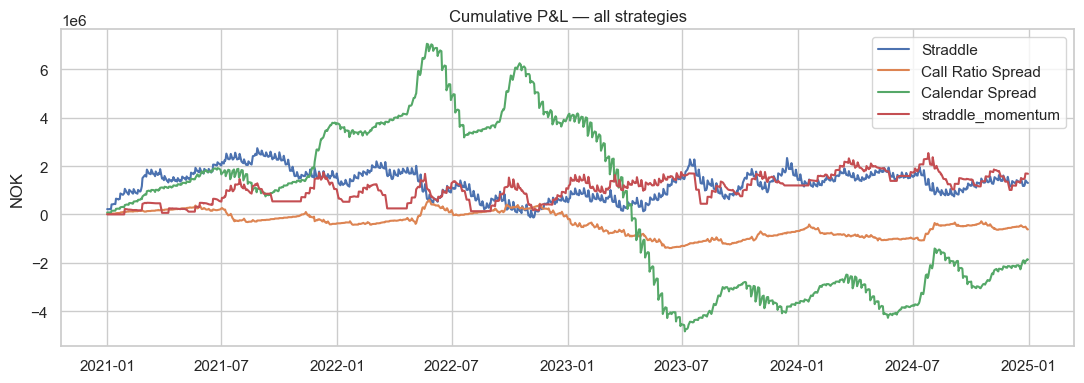

In [ ]:
import os

OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

# 1. Cumulative P&L for each strategy
cum_df = pd.DataFrame({name: r["daily_pnl"].cumsum() for name, r in runs.items()})
cum_df["straddle_momentum"] = res_sig["daily_pnl"].cumsum()
cum_df.to_csv(OUT / "cumulative_pnl.csv")

# 2. Metrics summary
pd.DataFrame({name: r["metrics"] for name, r in runs.items()}).T.to_csv(OUT / "metrics.csv")

# 3. Greeks attribution for the straddle
res_straddle["attribution"].to_csv(OUT / "straddle_greeks_attribution.csv")

# 4. Save the strategy comparison chart
fig, ax = plt.subplots(figsize=(11, 4))
for name in cum_df.columns:
    ax.plot(cum_df[name], label=name)
ax.set_title("Cumulative P&L — all strategies"); ax.set_ylabel("NOK"); ax.legend()
fig.tight_layout()
fig.savefig(OUT / "strategy_comparison.png", dpi=150)

print(f"Saved to {OUT.resolve()}")
